# Import Libraries

Grid search fusion weight alpha untuk:

```
prob_fused = alpha * prob_text + (1 - alpha) * prob_image
```

In [1]:
import json
import pickle
import re
from pathlib import Path
from urllib.parse import unquote, urlparse
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


I0000 00:00:1781666631.871238   83066 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781666631.874853   83066 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781666632.710769   83066 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781666636.410580   83066 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
def clean_url(url):
    parsed = urlparse(url)
    url = parsed.netloc + parsed.path
    url = unquote(url).lower()
    url = re.sub(r"https?:\/\/", "", url)
    url = re.sub(r"[-_/]", " ", url)
    url = re.sub(r"[^a-zA-Z0-9\s]", " ", url)
    url = re.sub(r"(\d)([a-z])", r"\1 \2", url)
    url = re.sub(r"([a-z])(\d)", r"\1 \2", url)
    url = re.sub(r"\s+", " ", url).strip()
    return url

In [3]:
BASE_DIR = Path(".")
BIN_DIR = BASE_DIR / "bin"
CSV_PATH = BASE_DIR / "dataset" / "dataset_crawl_070526_with_images_path.csv"

# Load Models

In [4]:
text_model = tf.keras.models.load_model(str(BIN_DIR / 'text_classifier.keras'))
with open(BIN_DIR / 'text_tfidf_vectorizer.pkl', 'rb') as f:
    text_vectorizer = pickle.load(f)
with open(BIN_DIR / 'text_best_threshold.json') as f:
    text_cfg = json.load(f)
text_threshold = text_cfg.get('best_threshold', 0.63)
print(f'Text threshold: {text_threshold:.2f}')

E0000 00:00:1781666639.199211   83066 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Text threshold: 0.63


In [5]:
image_model = tf.keras.models.load_model(str(BIN_DIR / 'image_classifier.keras'))
image_scaler = joblib.load(BIN_DIR / 'image_scaler.pkl')
with open(BIN_DIR / 'image_best_threshold.json') as f:
    image_cfg = json.load(f)
image_threshold = image_cfg['threshold']
print(f'Image threshold: {image_threshold:.2f}')
print(f'Image model: {type(image_model).__name__}')

Image threshold: 0.64
Image model: Sequential


# Load Dataset

In [6]:
df = pd.read_csv(CSV_PATH)
mask = df["Screenshot_Path"].notna() & (df["Screenshot_Path"] != "")
df_img = df[mask].copy().reset_index(drop=True)
X_img = np.load(BIN_DIR / 'image_features.npy')
img_ids = np.load(BIN_DIR / 'image_ids.npy')
id_map = {i: idx for idx, i in enumerate(img_ids)}
order = [id_map[wid] for wid in df_img["Webpage_id"]]
X_img = X_img[order]
y = (df_img["Tag"] == "gambling").astype(int).values
print(f'Samples: {len(df_img)}')
print(f'Gambling: {y.sum()} / Non-gambling: {(1 - y).sum()}')

Samples: 37811
Gambling: 12503 / Non-gambling: 25308


In [7]:
groups = df_img["Domain"].values

gkf = GroupKFold(n_splits=5)

oof_text_probs = np.zeros(len(df_img))
oof_image_probs = np.zeros(len(df_img))

# Predictions from Both Models

In [8]:
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(df_img, y, groups),
    1,
):

    print(f"\nFold {fold}/5")

    # ===================================
    # TEXT MODEL
    # ===================================

    X_text_train = (
        df_img.iloc[train_idx]["Url"]
        .apply(clean_url)
        .values
    )

    X_text_val = (
        df_img.iloc[val_idx]["Url"]
        .apply(clean_url)
        .values
    )

    X_train_tfidf = text_vectorizer.transform(X_text_train)
    X_val_tfidf = text_vectorizer.transform(X_text_val)

    fold_text_model = tf.keras.models.clone_model(
        text_model
    )

    fold_text_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0005
        ),
        loss="binary_crossentropy",
    )

    fold_text_model.fit(
        X_train_tfidf,
        y[train_idx],
        epochs=20,
        batch_size=64,
        verbose=0,
    )

    oof_text_probs[val_idx] = (
        fold_text_model.predict(
            X_val_tfidf,
            verbose=0,
        )
        .ravel()
    )

    # ===================================
    # IMAGE MODEL (Deep Learning)
    # ===================================

    fold_image_model = tf.keras.models.clone_model(image_model)
    fold_image_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, amsgrad=True),
        loss='binary_crossentropy',
    )

    fold_image_model.fit(
        X_img[train_idx],
        y[train_idx],
        epochs=20,
        batch_size=64,
        verbose=0,
    )

    oof_image_probs[val_idx] = (
        fold_image_model
        .predict(
            X_img[val_idx],
            verbose=0,
        )
        .ravel()
    )


Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5


In [9]:
prob_text = oof_text_probs
prob_image = oof_image_probs

# Grid Search Fusion Weight Alpha

In [10]:
results = []
best_alpha, best_f1, best_th = 0.5, 0.0, 0.5
for alpha in np.arange(0.0, 1.05, 0.05):
    prob_fused = alpha * prob_text + (1.0 - alpha) * prob_image
    best_f1_alpha, best_th_alpha = 0.0, 0.5
    for th in np.arange(0.3, 0.85, 0.02):
        f1 = f1_score(y, (prob_fused >= th).astype(int))
        if f1 > best_f1_alpha:
            best_f1_alpha, best_th_alpha = f1, th
    results.append({'alpha': round(alpha, 2), 'threshold': round(float(best_th_alpha), 2), 'f1': round(float(best_f1_alpha), 4)})
    if best_f1_alpha > best_f1:
        best_f1, best_alpha, best_th = best_f1_alpha, alpha, best_th_alpha

In [11]:
results_df = pd.DataFrame(results)
display(results_df)
text_f1 = f1_score(y, (prob_text >= text_threshold).astype(int))
image_f1 = f1_score(y, (prob_image >= image_threshold).astype(int))
print(f'\nText-only F1 (th={text_threshold:.2f}):  {text_f1:.4f}')
print(f'Image-only F1 (th={image_threshold:.2f}): {image_f1:.4f}')
print(f'\nBest alpha: {best_alpha:.2f}')
print(f'Threshold: {best_th:.2f}')
print(f'Fusion F1: {best_f1:.4f}')

,alpha,threshold,f1
0,0.00,0.48,0.8735
1,0.05,0.46,0.8796
2,0.10,0.48,0.8863
3,0.15,0.52,0.8937
4,0.20,0.56,0.9020
5,0.25,0.56,0.9116
6,0.30,0.54,0.9216
7,0.35,0.62,0.9330
8,0.40,0.58,0.9452
9,0.45,0.54,0.9578



Text-only F1 (th=0.63):  0.9594
Image-only F1 (th=0.64): 0.8645

Best alpha: 0.50
Threshold: 0.50
Fusion F1: 0.9781


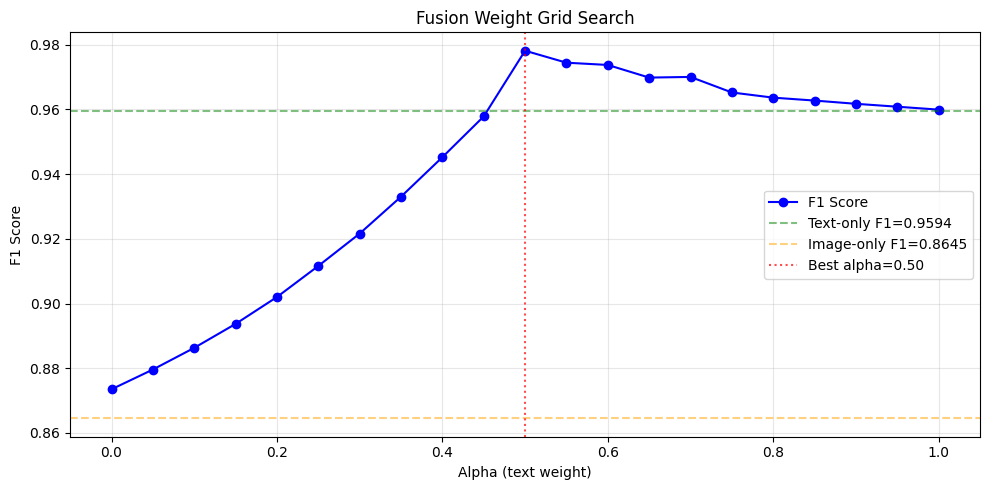

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(results_df['alpha'], results_df['f1'], 'bo-', label='F1 Score')
ax1.axhline(text_f1, color='green', linestyle='--', alpha=0.5, label=f'Text-only F1={text_f1:.4f}')
ax1.axhline(image_f1, color='orange', linestyle='--', alpha=0.5, label=f'Image-only F1={image_f1:.4f}')
ax1.axvline(best_alpha, color='red', linestyle=':', alpha=0.7, label=f'Best alpha={best_alpha:.2f}')
ax1.set_xlabel('Alpha (text weight)')
ax1.set_ylabel('F1 Score')
ax1.set_title('Fusion Weight Grid Search')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
best_prob_fused = (
    best_alpha * prob_text
    + (1.0 - best_alpha) * prob_image
)

best_pred = (
    best_prob_fused >= best_th
).astype(int)

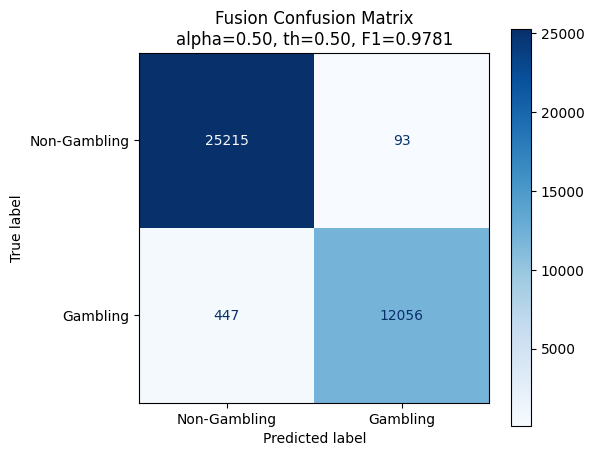

              precision    recall  f1-score   support

Non-Gambling     0.9826    0.9963    0.9894     25308
    Gambling     0.9923    0.9642    0.9781     12503

    accuracy                         0.9857     37811
   macro avg     0.9875    0.9803    0.9838     37811
weighted avg     0.9858    0.9857    0.9857     37811



In [14]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y,
    best_pred,
    display_labels=[
        "Non-Gambling",
        "Gambling",
    ],
    cmap="Blues",
    values_format="d",
    ax=ax,
)

ax.set_title(
    f"Fusion Confusion Matrix\n"
    f"alpha={best_alpha:.2f}, "
    f"th={best_th:.2f}, "
    f"F1={best_f1:.4f}"
)

plt.tight_layout()
plt.show()

print(
    classification_report(
        y,
        best_pred,
        target_names=[
            "Non-Gambling",
            "Gambling",
        ],
        digits=4,
    )
)

# Save Optimal Alpha

In [15]:
output = {'alpha': float(best_alpha), 'threshold': float(best_th), 'f1': float(best_f1)}
with open(BIN_DIR / 'image_fusion_alpha.json', 'w') as f:
    json.dump(output, f)
print(f'Saved to {BIN_DIR / "image_fusion_alpha.json"}')
print(json.dumps(output, indent=2))

Saved to bin/image_fusion_alpha.json
{
  "alpha": 0.5,
  "threshold": 0.5000000000000002,
  "f1": 0.9780950835631997
}
